# Aprendizaje Profundo
## Tarea 2: Redes convolucionales y transferencia
### Eduardo García Alarcón - PCIC
#### Ejercicio 2 - Clasificación de Rostros por grupo etario

- Dividir aleatoriamente el conjunto de entrenamiento en subconjuntos de entrenamiento y validación.
- Prgramar tu propia clase para la carga de datos.
- Agregar acrecentamiento de datos.
- Entrenar un modelo similar al de la libreta https://github.com/gibranfp/CursoAprendizajeProfundo/blob/2025-1/notebooks/2b_convnet_resnet.ipynb, pero cambiando los bloques ResNet por bloques ConvNeXt.

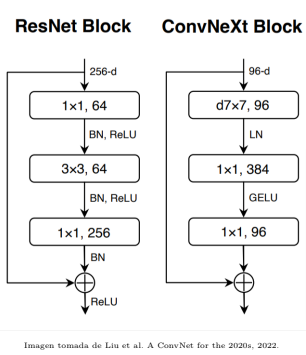

- Entrenar un modelo mediante aprendizaje por transferencia a partir de alguna red pre-entrenada actualizando solo los parámetros de la capa de salida y otro modelo actualizando los prámetrosd e toda la red.
- Graficar las pérdidas y métricas de entrenamiento y validación y discutir todos los resultados.

In [1]:
# Bibliotecas 図書館
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import pandas as pd

import torch as th
from torch import nn

# Por reproducibilidad
th.manual_seed(42)
np.random.seed(42)

LOGDIR = './logs/'
DC     = 'cuda:0' if th.cuda.is_available() else 'cpu'

N_IMGS_MUESTRA = 16
T_LOTE = 64
T_IMAGEN = 64
N_EPOCAS = 65

In [2]:
DC  

'cuda:0'

In [3]:
df = pd.read_csv('./fairface_label_train.csv')
df

,file,age,gender,race,service_test
0,train/1.jpg,50-59,Male,East Asian,True
1,train/2.jpg,30-39,Female,Indian,False
2,train/3.jpg,3-9,Female,Black,False
3,train/4.jpg,20-29,Female,Indian,True
4,train/5.jpg,20-29,Female,Indian,True
...,...,...,...,...,...
86739,train/86740.jpg,20-29,Male,Indian,True
86740,train/86741.jpg,10-19,Male,Indian,True
86741,train/86742.jpg,more than 70,Female,Indian,True
86742,train/86743.jpg,10-19,Female,Black,True


Agregamos una columna que contenga un valor numérico para la etiqueta de _race_

In [4]:
df.race = pd.Categorical(df.race)

In [5]:
df['race_ind'] = df.race.cat.codes

In [6]:
df

,file,age,gender,race,service_test,race_ind
0,train/1.jpg,50-59,Male,East Asian,True,1
1,train/2.jpg,30-39,Female,Indian,False,2
2,train/3.jpg,3-9,Female,Black,False,0
3,train/4.jpg,20-29,Female,Indian,True,2
4,train/5.jpg,20-29,Female,Indian,True,2
...,...,...,...,...,...,...
86739,train/86740.jpg,20-29,Male,Indian,True,2
86740,train/86741.jpg,10-19,Male,Indian,True,2
86741,train/86742.jpg,more than 70,Female,Indian,True,2
86742,train/86743.jpg,10-19,Female,Black,True,0


## fairface-img-margin025-trainval
Se asume que este archivo fue extraído en el mismo directorio que este notebook, por lo que las subcarpetas ``val`` y ``train`` están en alcanzables desde ``'./'``

In [7]:
dirPath = './'

In [8]:
t = plt.imread(dirPath + 'val/1.jpg')

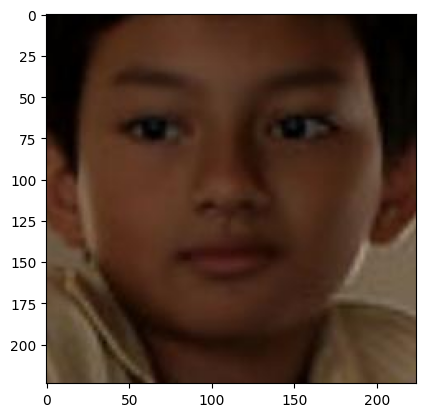

In [9]:
plt.imshow(t)

### Separamos el dataset de train en *entrenamiento* y *validación*
Usaremos el dataset de val como *testing*

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

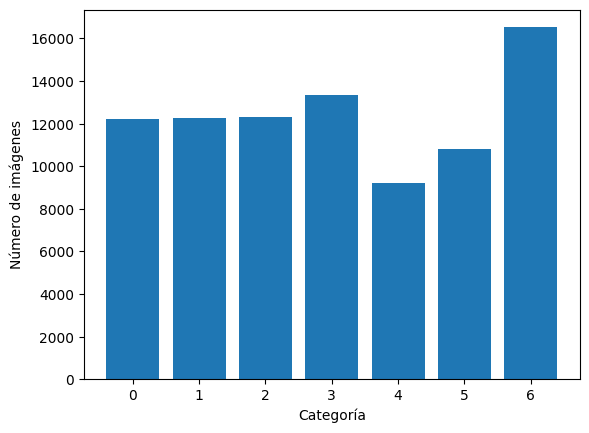

In [11]:
idx, cuentas = np.unique(df.race_ind, return_counts=True)
plt.bar(x=idx, height=cuentas)
plt.xlabel('Categoría')
plt.ylabel('Número de imágenes')
plt.show()

In [12]:
df_ent, df_val = train_test_split(df, 
                                                    test_size=.2, random_state=42, shuffle=True,
                                                    stratify=df.race_ind)

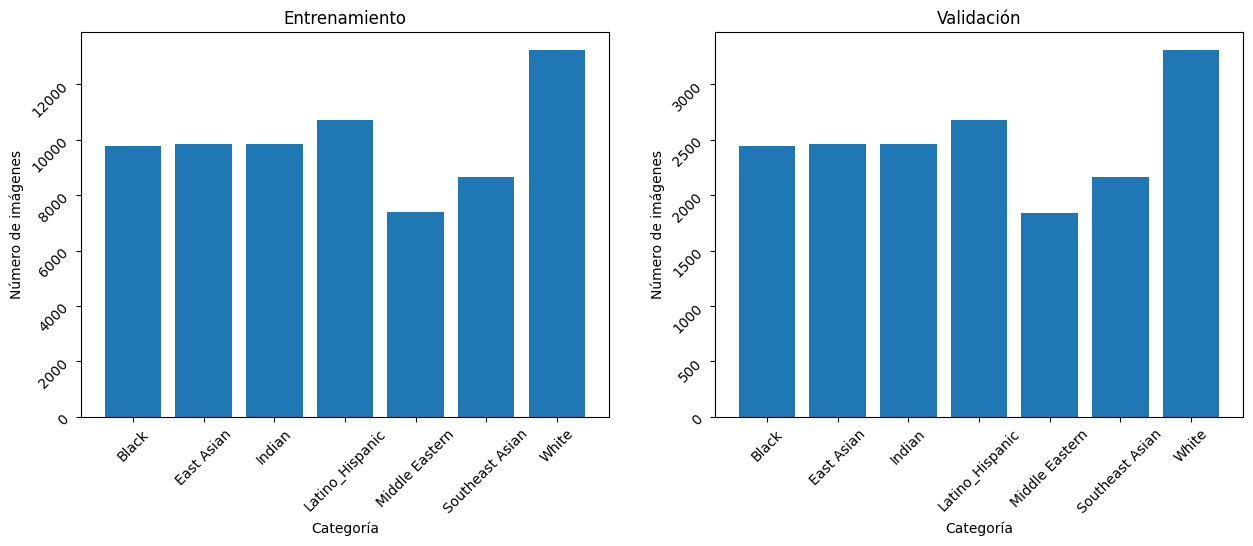

In [13]:
idx_ent, cuentas_ent = np.unique(df_ent.race, return_counts=True)
idx_val, cuentas_val = np.unique(df_val.race, return_counts=True)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

axs[0].bar(x=idx_ent, height=cuentas_ent)
axs[0].set_title('Entrenamiento')
axs[0].set_xlabel('Categoría')
axs[0].set_ylabel('Número de imágenes')
axs[0].tick_params(rotation=45)

axs[1].bar(x=idx_val, height=cuentas_val)
axs[1].set_title('Validación')
axs[1].set_xlabel('Categoría')
axs[1].set_ylabel('Número de imágenes')
axs[1].tick_params(rotation=45)

plt.show()

### Definimos el Data Loader

In [14]:
from torch.utils.data import Dataset
import os
import PIL

In [15]:
class FaceLoader(Dataset):
  def __init__(self, df, root, transform=None):
    self.df = df # El dataframe
    self.root = root # Ruta del directorio padre
    self.transform = transform # Transformaciones a las imágenes

  def __getitem__(self, idx):
    # Abrimos la imagen
    img = PIL.Image.open(self.root + self.df.file.iloc[idx])
    # Obtenemos la categoría del dataframe
    cat = self.df.race_ind.iloc[idx]

    # En caso de tener una transformación
    if self.transform:
      img = self.transform(img)

    return img, th.tensor(cat, dtype=th.long)
  
  def __len__(self):
    return len(self.df)

In [16]:
def muestra_imagenes(imgs, etiq):
  t_muestra = imgs.shape[0]
  n_filas = n_cols = int(np.sqrt(t_muestra))

  fig, ax = plt.subplots(nrows=n_filas, ncols=n_cols, figsize=(2 * n_filas,
                                                               2 * n_cols))
  for i in range(n_filas):
    for j in range(n_cols):
      idx = i * n_filas + j
      ax[i, j].imshow(imgs[idx])
      ax[i, j].axis('off')
      ax[i, j].set_title(etiq[idx])
  plt.tight_layout()
  plt.show()

#### Instanciamos objetos para cargar las imágenes

In [17]:
ds_ent = FaceLoader(df=df_ent, root=dirPath)
ds_val = FaceLoader(df=df_val, root=dirPath)

In [18]:
# Definimos un iterador para poder ir cargando las imágenes
it_ent = iter(ds_ent)
img_ent, cat_ent = next(it_ent)

print(f'{img_ent = }, {cat_ent = }')

img_ent = <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x7F5B9EB90400>, cat_ent = tensor(3)


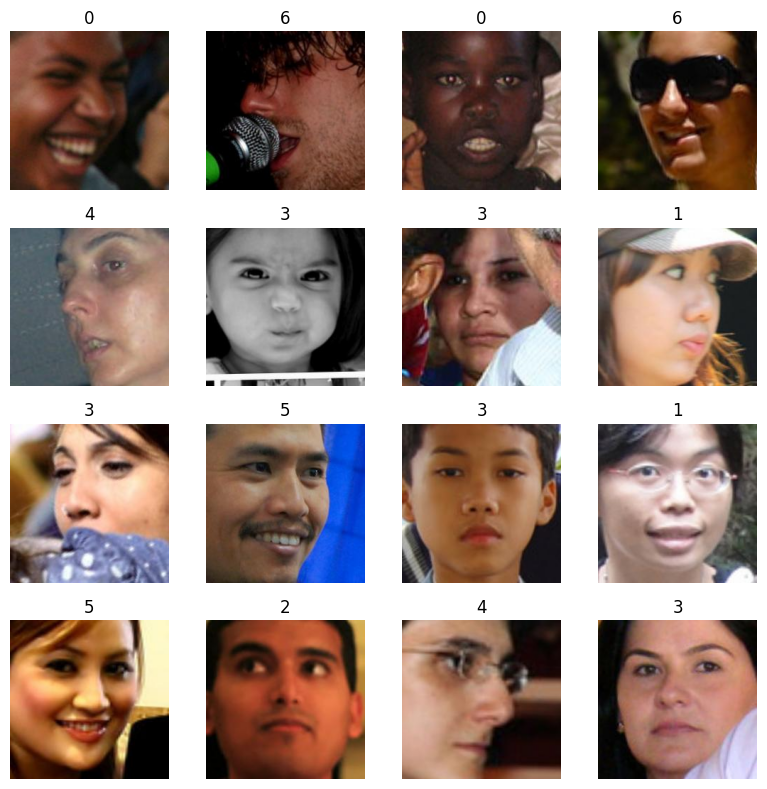

In [19]:
muestras = [next(it_ent) for i in range(N_IMGS_MUESTRA)]
imgs = [np.array(m[0]) for m in muestras]
cats = [m[1] for m in muestras]

muestra_imagenes(np.array(imgs), np.array(cats))

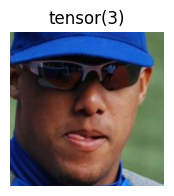

Imagen = <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x7F5B9E5894C0>, Categoría = 3


In [20]:
it_val = iter(ds_val)
img_prueba, cat_prueba = next(it_val)

plt.figure(figsize = (2,2))
plt.imshow(img_prueba)
plt.title(cat_prueba)
plt.axis('off')
plt.show()

print(f'Imagen = {img_prueba}, Categoría = {cat_prueba}')

In [21]:
df.race_ind

0        1
1        2
2        0
3        2
4        2
        ..
86739    2
86740    2
86741    2
86742    0
86743    6
Name: race_ind, Length: 86744, dtype: int8

### Acrecentamiento de datos
Definimos una transformación para el acrecentamiento de nuestros datos

Las imágenes con las que estamos trabajando son tomadas desde distintas perspectivas, por lo que un acrecentamiento en ese aspecto no creo que sea tan relevante. Por otra parte el ángulo es más o menos el mismo (al menos en las que vi), por lo que se hará esa tranformación, _espero que sirva de algo_.

In [22]:
import torchvision.transforms as T

/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (2.0.2) or chardet (5.1.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [23]:
tr_ent = T.Compose([
  # Aplicamos un randon size crop para tener imágenes más pequeñas 
  # (y por ende más rápidas de procesar)
  T.RandomResizedCrop(64, scale=(.85, 1.0), antialias=True), #64x64 como en el notebook
  # Giramos aleatoriamente en el eje horizontal
  T.RandomHorizontalFlip(),
  # Hacemos una rotación aleatoria
  T.RandomRotation(degrees=(0,180)),
  # Por ultimo hacemos que la imagen sea un tensor
  # T.ToImage(),
  # T.ToDtype(th.float32, scale=True)
  T.ToTensor()
])

In [24]:
tr_val = T.Compose([
  T.Resize(64, antialias=True),
  # T.ToImage(),
  # T.ToDtype(th.float32, scale=True)
  T.ToTensor()
])

#### Repetimos lo de arriba, pero con las nuevas transformaciones para el acrecentamiento de datos

In [25]:
ds_ent.transform = tr_ent
ds_val.transform = tr_val

In [26]:
# Definimos un iterador para poder ir cargando las imágenes
it_ent = iter(ds_ent)
img_ent, cat_ent = next(it_ent)

print(f'{img_ent.shape = }, {cat_ent = }')

img_ent.shape = torch.Size([3, 64, 64]), cat_ent = tensor(3)


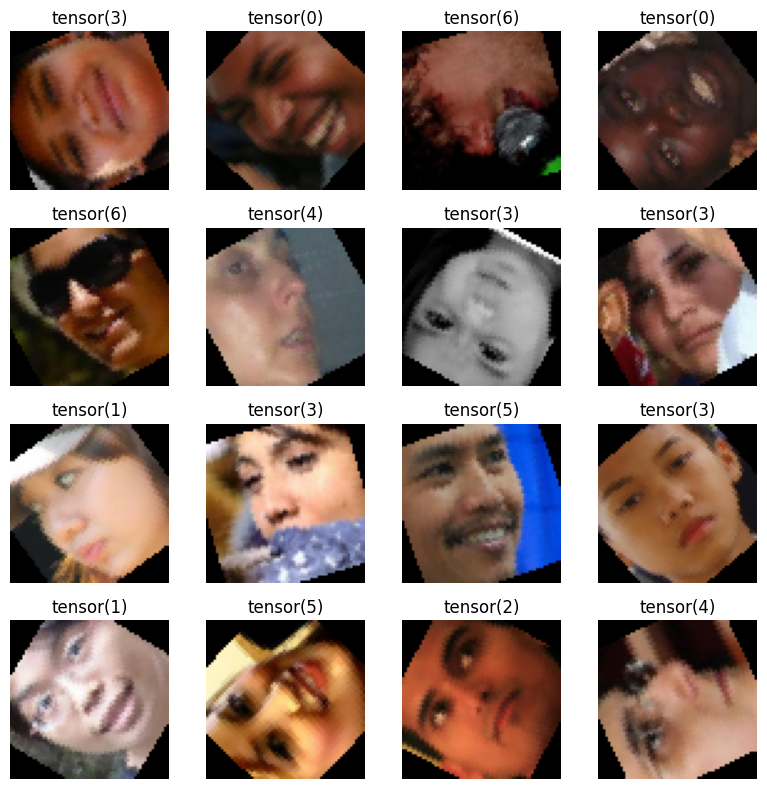

In [27]:
it = iter(ds_ent)
muestras = [next(it) for i in range(N_IMGS_MUESTRA)]
imgs = [np.array(m[0].permute(1, 2, 0)) for m in muestras]
cats = [m[1] for m in muestras]

muestra_imagenes(np.array(imgs), cats)

Como podemos observar arriba, ahora las imágenes tiene el formato correcto de Tensor que es $(C ,H,W)$

#### Utilizamos el DataLoader para hacer batches de entrenamiento

In [28]:
from torch.utils.data import DataLoader

In [29]:
entdl = DataLoader(ds_ent,
                   batch_size=T_LOTE,
                   shuffle=True)

valdl = DataLoader(ds_val,
                   batch_size=T_LOTE,
                   shuffle=True)

### Funciones para el entrenamiento

In [30]:
from torch.utils.tensorboard import SummaryWriter

def registra_info_tboard(writer, epoca, hist):
  for (m,v) in hist.items():
    writer.add_scalar(m, v[epoca], epoca)

def guarda_ckpt(ckptpath, modelo, epoca, opt):
  estado_modelo = {'epoch': epoca,
                   'model_state_dict': modelo.state_dict(),
                   'optimizer_state_dict': opt.state_dict()}
  th.save(estado_modelo, ckptpath)

def exactitud(y_hat, y):
  cmp = y_hat.argmax(dim=-1) == y
  aciertos = th.count_nonzero(cmp)
  return aciertos / cmp.shape[0]

def paso_ent(modelo,
             fp,
             metrica,
             opt,
             X,
             y):
  opt.zero_grad() # se ponen los gradientes asociados a los parámetros
                    # a actualizaren en cero
  y_hat = modelo(X) # se propagan las entradas para obtener las predicciones
  perdida = fp(y_hat, y) # se calcula la pérdida
  perdida.backward() # se obtienen los gradientes
  opt.step() # se actualizan todos los parámetros del modelo

  with th.no_grad():
    perdida_paso = perdida.cpu().numpy() # convertimos la pérdida (instancia de
                                         # Tensor de orden 0) a NumPy, para
                                         # lo que es necesario moverla a CPU
    metricas_paso = metrica(y_hat, y)

  return perdida_paso, metricas_paso

In [31]:
import copy

def entrena(modelo,
            fp,
            metrica,
            opt,
            entdl,
            valdl,
            disp,
            ckptpath,
            n_epocas = 10,
            tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {'perdida_ent':np.zeros(n_epocas),
          'perdida_val': np.zeros(n_epocas),
          metrica.__name__ + '_ent': np.zeros(n_epocas),
          metrica.__name__ + '_val': np.zeros(n_epocas)}

  tbwriter = SummaryWriter(tbdir)
  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in trange(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for p, (Xlote,ylote) in enumerate(entdl):
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)

      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist['perdida_ent'][e] += perdida_paso
      hist[metrica.__name__ + '_ent'][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote in valdl:
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp)

        y_hat = modelo(Xlote)

        hist['perdida_val'][e] += fp(y_hat, ylote)
        hist[metrica.__name__ + '_val'][e] += metrica(y_hat, ylote)

    hist['perdida_ent'][e] /=  n_lotes_ent
    hist[metrica.__name__ + '_ent'][e] /= n_lotes_ent
    hist['perdida_val'][e] /=  n_lotes_val
    hist[metrica.__name__ + '_val'][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['perdida_val'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)
      perdida_min = hist['perdida_val'][e]

    registra_info_tboard(tbwriter, e, hist)

    print(f'\nÉpoca {e}: '
          f'Perdida(E) = {hist["perdida_ent"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist[metrica.__name__ + "_ent"][e]:.3f}, '
          f'Perdida(V) = {hist["perdida_val"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist[metrica.__name__ + "_val"][e]:.3f}')

  return modelo, mejor_modelo, hist

### Arquitecturas

In [32]:
class Base(nn.Module):
  def __init__(self, cent, csal, downsample=False):
    super(Base, self).__init__()
    stride = 1
    if downsample:
      stride = 2
    if cent != csal or downsample:
      self.conv1x1 = nn.Conv2d(cent, csal, 1, stride=stride, padding=0)
    else:
      self.conv1x1 = None

    self.conv1 = nn.Conv2d(cent, csal, 7, padding=3, groups=cent)
    self.layerNorm = nn.LayerNorm([csal, 16, 16]) #Porque las imagenes son de  64x64
    self.conv2 = nn.Conv2d(csal, 4*csal, 1, padding='same')
    self.gelu = nn.GELU()
    self.conv3 = nn.Conv2d(4*csal, csal, 1)

  def forward(self, x):
    y = self.conv1(x)
    y = self.layerNorm(y) 
    y = self.conv2(y)
    y = self.gelu(y)
    y = self.conv3(y)

    # print(f'{y.shape=}')
    if self.conv1x1:
      x = self.conv1x1(x)

    # print(f'{x.shape=}')
    return y + x


In [33]:
res = Base(4, 16)
print(res(th.rand(1, 4, 16, 16)).shape)

torch.Size([1, 16, 16, 16])


In [34]:
# Definimos el bloque ConvNeXt
class BloqueConvNeXt(nn.Module):
  def __init__(self, cent, csal, k=2, downsample=False):
    # init de la clase padre
    super(BloqueConvNeXt, self).__init__()

    self.bas = [Base(cent, csal, downsample=downsample)]
    for i in range(k):
      self.bas.append(Base(csal, csal))
    self.bas = nn.ModuleList(self.bas)

  def forward(self, x):
    for b in self.bas:
      x = b(x)
    return x

In [35]:
b = BloqueConvNeXt(96,96)
print(b(th.rand(1, 96, 16, 16)).shape)

torch.Size([1, 96, 16, 16])


In [36]:
class ConvNeXt(nn.Module):
    def __init__(self, n_classes):
        super(ConvNeXt, self).__init__()
        self.conv1 = nn.Conv2d(3, 96, kernel_size=7, stride=2, padding=3)  # Capa de conv inicial
        self.mp1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  # Capa de max pooling

        # Apilamiento de bloques ConvNeXt similar al de la notebook de clase
        self.b1 = BloqueConvNeXt(96, 96)
        self.b2 = BloqueConvNeXt(96, 192)
        self.b3 = BloqueConvNeXt(192, 384)
        self.b4 = BloqueConvNeXt(384, 768)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # Global average pooling
        self.fc = nn.Linear(768, n_classes)  # Capa Fully Conected para la clasificacio

    def forward(self, x):
        # print(f'Entrada {x.shape=}')
        x = self.conv1(x)
        # print(f'conv1 {x.shape=}')
        x = self.mp1(x)
        # print(f'mp1 {x.shape=}')
        x = self.b1(x)
        # print(f'b1 {x.shape=}')
        x = self.b2(x)
        # print(f'b2 {x.shape=}')
        x = self.b3(x)
        # print(f'b3 {x.shape=}')
        x = self.b4(x)
        # print(f'b4 {x.shape=}')
        x = self.gap(x)
        # print(f'gap {x.shape=}')
        x = x.flatten(start_dim=1)
        # print(f'flatten {x.shape=}')
        x = self.fc(x)
        # print(f'fc {x.shape=}')

        return x


In [37]:
from torch.optim import Adam

In [38]:
num_clases = len(df.race.unique())
num_clases

7

In [40]:
convnext = ConvNeXt(num_clases).to(DC)
LOGDIR = './logs/'

perdida = nn.CrossEntropyLoss(weight=None,
                              reduction='mean',
                              label_smoothing=0.1)
opt = Adam(convnext.parameters(),
           lr=0.001)

convnext, mejor_convnext, hist = entrena(convnext,
                                     perdida,
                                     exactitud,
                                     opt,
                                     entdl,
                                     valdl,
                                     DC,
                                     LOGDIR + 'convnext.pt',
                                     n_epocas=N_EPOCAS,
                                     tbdir = LOGDIR)

  2%|▏         | 1/65 [04:37<4:55:31, 277.05s/it]


Época 0: Perdida(E) = 2.126, exactitud(E) = 0.216, Perdida(V) = 1.890, exactitud(V) = 0.232


  3%|▎         | 2/65 [09:14<4:51:00, 277.15s/it]


Época 1: Perdida(E) = 1.845, exactitud(E) = 0.270, Perdida(V) = 1.823, exactitud(V) = 0.290


  5%|▍         | 3/65 [13:51<4:46:23, 277.15s/it]

...


Época 62: Perdida(E) = 1.096, exactitud(E) = 0.682, Perdida(V) = 1.318, exactitud(V) = 0.568


 98%|█████████▊| 64/65 [4:54:10<04:35, 275.51s/it]


Época 63: Perdida(E) = 1.092, exactitud(E) = 0.685, Perdida(V) = 1.356, exactitud(V) = 0.559


100%|██████████| 65/65 [4:58:45<00:00, 275.77s/it]


Época 64: Perdida(E) = 1.086, exactitud(E) = 0.689, Perdida(V) = 1.332, exactitud(V) = 0.571


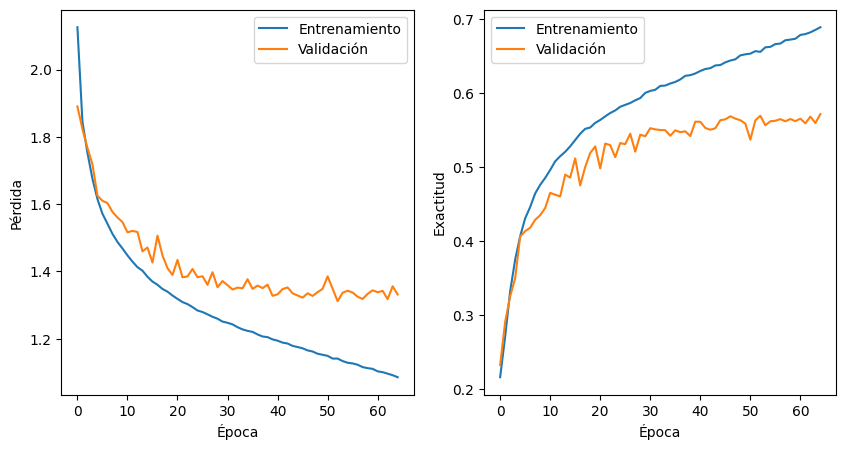

In [41]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(hist['perdida_ent'], label='Entrenamiento')
axs[0].plot(hist['perdida_val'], label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(hist['exactitud_ent'], label='Entrenamiento')
axs[1].plot(hist['exactitud_val'], label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Exactitud')
axs[1].legend()
plt.show()

### Aprendizaje por Transferencia

In [42]:
# Revisamos los modelos existentes dentro de tochvision para usar alguno
import torchvision as tv

tv.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [43]:
model = tv.models.googlenet(weights=tv.models.GoogLeNet_Weights.IMAGENET1K_V1)

Como no queremos entrenar esta red desde el inicio, debemos cambiar el parámetro de las capas ``requires_grad = False``

In [44]:
for c in model.parameters():
  c.requires_grad = False

Ponemos el modelo en modo evaluación

In [45]:
model.eval()

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

Agregamos una capa fully connected al modelo que tenga la cantidad de salidas adecuadas para nuestro problema

In [46]:
model.fc = nn.Linear(1024, num_clases)

Entrenamiento de transferencia

In [47]:
import copy

def entrena_transferencia(modelo,
                          fp,
                          metrica,
                          opt,
                          entdl,
                          valdl,
                          disp,
                          ckptpath,
                          n_epocas = 50,
                          tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {
    'ent': {
      'perdida': np.zeros(n_epocas),
      metrica.__name__: np.zeros(n_epocas)
      },
    'val': {
      'perdida': np.zeros(n_epocas),
      metrica.__name__: np.zeros(n_epocas)
      }
  }

  tbwriter_ent = SummaryWriter(tbdir + '/ent')
  tbwriter_val = SummaryWriter(tbdir + '/val')

  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in trange(n_epocas):
    # bucle de entrenamiento
    modelo.fc.train()
    for Xlote,ylote in entdl:
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)

      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist["ent"]['perdida'][e] += perdida_paso
      hist["ent"][metrica.__name__][e] += metrica_paso

    # bucle de validación
    modelo.fc.eval()
    with th.no_grad():
      for Xlote,ylote in valdl:
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp)

        y_hat = modelo(Xlote)

        hist['val']['perdida'][e] += fp(y_hat, ylote)
        hist['val'][metrica.__name__][e] += metrica(y_hat, ylote)

    hist['ent']['perdida'][e] /=  n_lotes_ent
    hist['ent'][metrica.__name__][e] /= n_lotes_ent
    hist['val']['perdida'][e] /=  n_lotes_val
    hist['val'][metrica.__name__][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['val']['perdida'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)

    registra_info_tboard(tbwriter_ent, e, hist['ent'])
    registra_info_tboard(tbwriter_val, e, hist['val'])

    print(f'\nÉpoca {e}: '
          f'Perdida(E) = {hist["ent"]["perdida"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist["ent"][metrica.__name__][e]:.3f}, '
          f'Perdida(V) = {hist["val"]["perdida"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist["val"][metrica.__name__][e]:.3f}')

  return modelo, mejor_modelo, hist

In [48]:
from torch.optim import Adam

model.to(DC)
perdida = nn.CrossEntropyLoss(weight=None,
                              reduction='mean',
                              label_smoothing=0.01)
opt = Adam(model.parameters(),
           lr=0.001)

modelo, mejor_modelo, hist = entrena_transferencia(model,
                                                   perdida,
                                                   exactitud,
                                                   opt,
                                                   entdl,
                                                   valdl,
                                                   DC,
                                                   LOGDIR + '/googlenet_tl.pt',
                                                   n_epocas=N_EPOCAS,
                                                   tbdir = LOGDIR)

  2%|▏         | 1/65 [01:15<1:21:01, 75.96s/it]


Época 0: Perdida(E) = 1.849, exactitud(E) = 0.268, Perdida(V) = 1.859, exactitud(V) = 0.267


  3%|▎         | 2/65 [02:32<1:19:52, 76.07s/it]


Época 1: Perdida(E) = 1.810, exactitud(E) = 0.290, Perdida(V) = 1.873, exactitud(V) = 0.256


  5%|▍         | 3/65 [03:48<1:18:36, 76.07s/it]

...


Época 62: Perdida(E) = 1.795, exactitud(E) = 0.299, Perdida(V) = 1.866, exactitud(V) = 0.253


 98%|█████████▊| 64/65 [1:21:33<01:16, 76.72s/it]


Época 63: Perdida(E) = 1.803, exactitud(E) = 0.295, Perdida(V) = 1.976, exactitud(V) = 0.254


100%|██████████| 65/65 [1:22:49<00:00, 76.46s/it]


Época 64: Perdida(E) = 1.798, exactitud(E) = 0.298, Perdida(V) = 1.911, exactitud(V) = 0.252


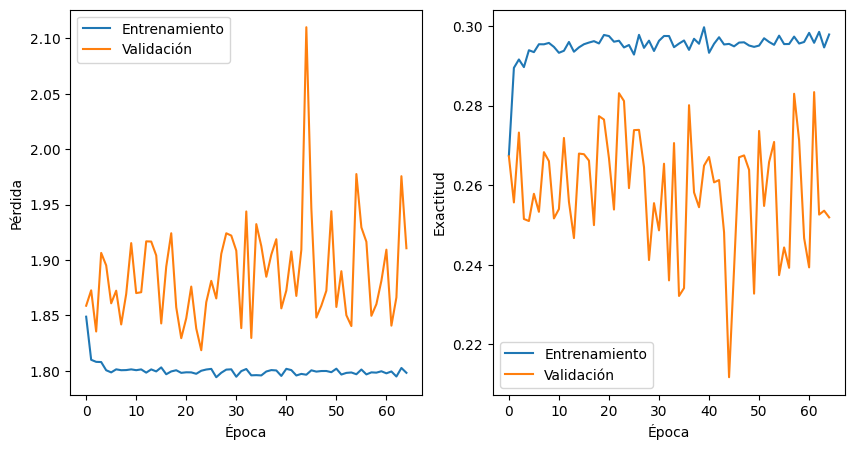

In [49]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(hist['ent']['perdida'], label='Entrenamiento')
axs[0].plot(hist['val']['perdida'], label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(hist['ent']['exactitud'], label='Entrenamiento')
axs[1].plot(hist['val']['exactitud'], label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Exactitud')
axs[1].legend()
plt.show()

### Transferencia y Ajuste Fino

Me arrojó un error muy raro de que los datos no se encuentran en el mismo dispositivo. Y no lo pude arreglar, por lo que la suiguiente sección se encuentra sin resultados

In [57]:
def entrena_ajuste_fino(modelo,
                        fp,
                        metrica,
                        opt,
                        entdl,
                        valdl,
                        disp,
                        ckptpath,
                        n_epocas = 10,
                        tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {
    'ent': {
      'perdida': np.zeros(n_epocas),
      metrica.__name__: np.zeros(n_epocas)
      },
    'val': {
      'perdida': np.zeros(n_epocas),
      metrica.__name__: np.zeros(n_epocas)
      }
  }

  tbwriter_ent = SummaryWriter(tbdir + '/ent')
  tbwriter_val = SummaryWriter(tbdir + '/val')

  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in range(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for Xlote,ylote in entdl:
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)

      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist["ent"]['perdida'][e] += perdida_paso
      hist["ent"][metrica.__name__][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote in valdl:
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp)

        y_hat = modelo(Xlote)

        hist['val']['perdida'][e] += fp(y_hat, ylote)
        hist['val'][metrica.__name__][e] += metrica(y_hat, ylote)

    hist['ent']['perdida'][e] /=  n_lotes_ent
    hist['ent'][metrica.__name__][e] /= n_lotes_ent
    hist['val']['perdida'][e] /=  n_lotes_val
    hist['val'][metrica.__name__][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['val']['perdida'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)

    registra_info_tboard(tbwriter_ent, e, hist['ent'])
    registra_info_tboard(tbwriter_val, e, hist['val'])

    print(f'\nÉpoca {e}: '
          f'Perdida(E) = {hist["ent"]["perdida"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist["ent"][metrica.__name__][e]:.3f}, '
          f'Perdida(V) = {hist["val"]["perdida"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist["val"][metrica.__name__][e]:.3f}')

  return modelo, mejor_modelo, hist

Nos aseguramos que ``requires_grad = True``

In [60]:
for p in model.parameters():
  p.requires_grad = True

In [ ]:
model = tv.models.googlenet(weights=tv.models.GoogLeNet_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(1024, num_clases)
modelo.to(DC)


perdida = nn.CrossEntropyLoss(weight=None,
                              reduction='mean',
                              label_smoothing=0.01)
opt = Adam(model.parameters(),
           lr=0.0001)

model, mejor_model, hist = entrena_ajuste_fino(model,
                                                 perdida,
                                                 exactitud,
                                                 opt,
                                                 entdl,
                                                 valdl,
                                                 DC,
                                                 LOGDIR + '/googlenet_tlft.pt',
                                                 n_epocas=N_EPOCAS,
                                                 tbdir = LOGDIR)